 Imports

In [ ]:
!pip install tensorflow-datasets --upgrade -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pathlib
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)
from sklearn.metrics import classification_report, confusion_matrix
import time

print("TensorFlow:", tf.__version__)
print("All libraries loaded!")

TensorFlow: 2.20.0
All libraries loaded!


Download the Flowers Dataset

In [ ]:
# Download Flowers dataset directly from Google's servers

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    origin  = dataset_url,
    fname   = 'flower_photos',
    untar   = True
)

data_dir = pathlib.Path(data_dir)

print("Dataset downloaded!")
print("Location:", data_dir)

# Count total images
image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:", image_count)

# Show folder structure
print("\nFolders inside dataset:")
for folder in sorted(data_dir.iterdir()):
    if folder.is_dir():
        count = len(list(folder.glob('*.jpg')))
        print(f"  {folder.name:15} → {count} images")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Dataset downloaded!
Location: /root/.keras/datasets/flower_photos
Total images: 0

Folders inside dataset:
  flower_photos   → 0 images


In [ ]:
# The actual images are one folder deeper
# Let's find the correct path

import os

# Check what's inside
print("Contents of data_dir:")
for item in sorted(data_dir.iterdir()):
    print(" ", item)

Contents of data_dir:
  /root/.keras/datasets/flower_photos/flower_photos


In [ ]:
# Fix the nested path
data_dir = data_dir / 'flower_photos'

print("Updated path:", data_dir)

image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:", image_count)

print("\nFolders:")
for folder in sorted(data_dir.iterdir()):
    if folder.is_dir():
        count = len(list(folder.glob('*.jpg')))
        print(f"  {folder.name:15} → {count} images")

Updated path: /root/.keras/datasets/flower_photos/flower_photos
Total images: 3670

Folders:
  daisy           → 633 images
  dandelion       → 898 images
  roses           → 641 images
  sunflowers      → 699 images
  tulips          → 799 images


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset           = 'training',
    seed             = 42,
    image_size       = (IMG_SIZE, IMG_SIZE),
    batch_size       = BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset           = 'validation',
    seed             = 42,
    image_size       = (IMG_SIZE, IMG_SIZE),
    batch_size       = BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes    :", class_names)
print("Num classes:", num_classes)
print("Train batches:", len(train_ds))
print("Val batches  :", len(val_ds))

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes    : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Num classes: 5
Train batches: 92
Val batches  : 23


Normalize and Augment.

In [ ]:
# Normalize pixels from 0-255 to 0-1
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Augmentation — random flips, brightness, contrast
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Apply to training set — preprocess + augment
train_ds = (train_ds
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .map(augment,    num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

# Apply to val set — only preprocess, NO augmentation
val_ds = (val_ds
          .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
          .prefetch(tf.data.AUTOTUNE))

# Test set = same as val for this dataset
test_ds = val_ds

print("Preprocessing done!")
print("Train → normalized + augmented")
print("Val   → normalized only")

Preprocessing done!
Train → normalized + augmented
Val   → normalized only


Visualize Sample Images

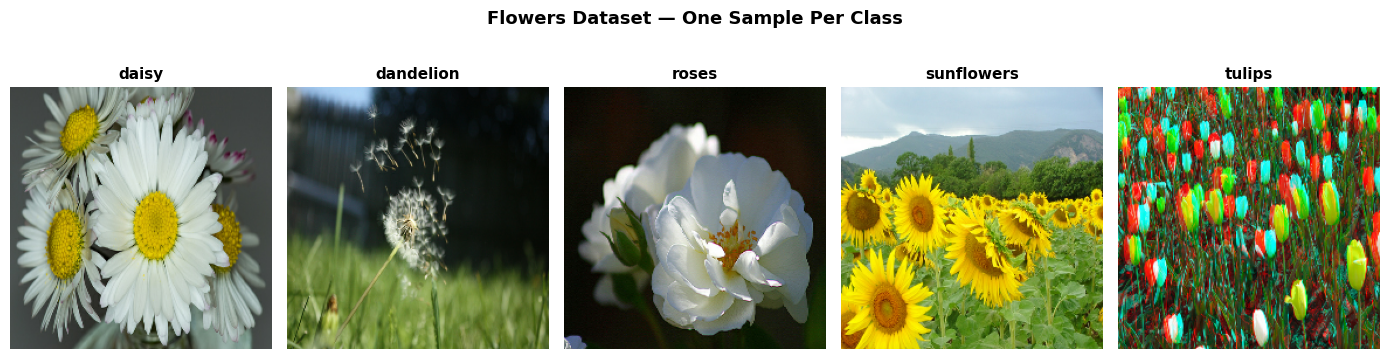

In [ ]:
# Show one sample image from each class
plt.figure(figsize=(14, 4))

# Get one batch from validation set
for images, labels in val_ds.take(1):
    # Find one image per class
    seen = {}
    for i in range(len(labels)):
        label = labels[i].numpy()
        if label not in seen:
            seen[label] = images[i].numpy()
        if len(seen) == num_classes:
            break

    # Plot
    for idx, (label, img) in enumerate(sorted(seen.items())):
        plt.subplot(1, num_classes, idx+1)
        plt.imshow(img)
        plt.title(class_names[label], fontsize=11,
                  fontweight='bold')
        plt.axis('off')

plt.suptitle('Flowers Dataset — One Sample Per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Found 3670 files belonging to 5 classes.


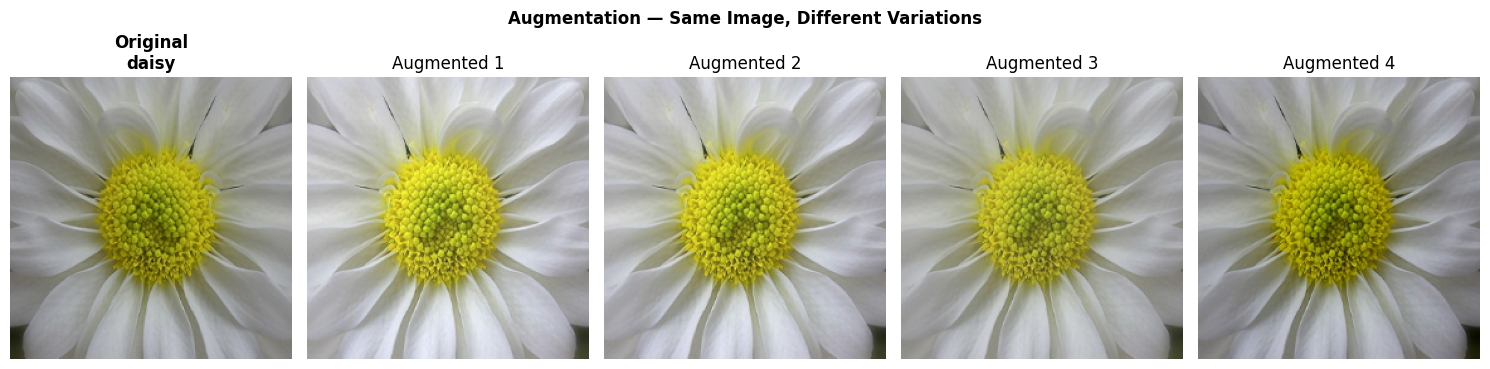

In [ ]:
# Show the same image before and after augmentation
# Get one raw image from disk first
raw_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = 1,
    shuffle    = False
)

# Get first image
for raw_img, raw_label in raw_ds.take(1):
    original = tf.cast(raw_img[0], tf.float32) / 255.0
    label    = class_names[raw_label[0].numpy()]

# Apply augmentation 4 times to same image
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(original.numpy())
axes[0].set_title('Original\n' + label, fontweight='bold')
axes[0].axis('off')

for i in range(4):
    aug_img, _ = augment(original, 0)
    axes[i+1].imshow(aug_img.numpy())
    axes[i+1].set_title(f'Augmented {i+1}')
    axes[i+1].axis('off')

plt.suptitle('Augmentation — Same Image, Different Variations',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Build the Model

In [ ]:
# Load MobileNetV2 with ImageNet weights
# include_top=False removes the original ImageNet classifier
base_model = MobileNetV2(
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    include_top = False,
    weights     = 'imagenet'
)

# Freeze all base layers
# We don't want to change pretrained weights yet
base_model.trainable = False

print(f"Base model total layers : {len(base_model.layers)}")
print(f"Trainable layers        : {len([l for l in base_model.layers if l.trainable])}")
print(f"Frozen layers           : {len([l for l in base_model.layers if not l.trainable])}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model total layers : 154
Trainable layers        : 0
Frozen layers           : 154


In [ ]:
# Build full model
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass through frozen MobileNetV2
x = base_model(inputs, training=False)

# GlobalAveragePooling converts feature maps to a flat vector
x = layers.GlobalAveragePooling2D()(x)

# Our new classification layers
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Output — 5 neurons for 5 flower classes
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs,
                    name='MobileNetV2_Flowers')

model.summary()

Model: "MobileNetV2_Flowers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,581 (10.01 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Compile and Train Phase

In [ ]:
# Phase 1 — Train only our new head
# Base is completely frozen

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(
        monitor             = 'val_accuracy',
        patience            = 5,
        restore_best_weights= True,
        verbose             = 1
    ),
    ModelCheckpoint(
        'best_phase1.keras',
        monitor       = 'val_accuracy',
        save_best_only= True,
        verbose       = 0
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        verbose  = 1
    )
]

print("Phase 1 — Training new head only...")
print("Base model: FROZEN")
print("Learning rate: 0.001\n")

start = time.time()

history1 = model.fit(
    train_ds,
    epochs          = 5,
    validation_data = val_ds,
    callbacks       = callbacks_phase1,
    verbose         = 1
)

time1 = time.time() - start
best1 = max(history1.history['val_accuracy'])

print(f"\nPhase 1 complete!")
print(f"Time            : {time1/60:.1f} minutes")
print(f"Best val accuracy: {best1:.4f}")

Phase 1 — Training new head only...
Base model: FROZEN
Learning rate: 0.001

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 243ms/step - accuracy: 0.8842 - loss: 0.3365 - val_accuracy: 0.8801 - val_loss: 0.3641 - learning_rate: 0.0010
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.9104 - loss: 0.2402 - val_accuracy: 0.8937 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.9162 - loss: 0.2416 - val_accuracy: 0.8883 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 4/5
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9309 - loss: 0.1946
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.9332 - loss: 0.1874 - val_accuracy: 0.8801 - val_loss: 0.4349 - learning_rate: 0.0010
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.9438 - loss: 0.1471 - val_accuracy: 0.8924 - val_loss: 0.4173 - learning_rate: 5.0000e-04
Restoring

Fine Tuning

In [ ]:
# Unfreeze last 30 layers of MobileNetV2
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Total base layers    : {len(base_model.layers)}")
print(f"Now trainable        : {len([l for l in base_model.layers if l.trainable])}")
print(f"Still frozen         : {len([l for l in base_model.layers if not l.trainable])}")

# Recompile with very small learning rate
# Critical — large lr would destroy pretrained weights
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        'best_phase2.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 0
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        verbose  = 1
    )
]

print("\nPhase 2 — Fine tuning last 30 layers...")
print("Learning rate: 0.00001 (100x smaller than Phase 1)\n")

start = time.time()

history2 = model.fit(
    train_ds,
    epochs          = 10,
    validation_data = val_ds,
    callbacks       = callbacks_phase2,
    verbose         = 1
)

time2 = time.time() - start
best2 = max(history2.history['val_accuracy'])

print(f"\nPhase 2 complete!")
print(f"Time             : {time2/60:.1f} minutes")
print(f"Best val accuracy: {best2:.4f}")
print(f"Improvement      : +{(best2 - 0.8937)*100:.2f}%")

Total base layers    : 154
Now trainable        : 30
Still frozen         : 124

Phase 2 — Fine tuning last 30 layers...
Learning rate: 0.00001 (100x smaller than Phase 1)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 311ms/step - accuracy: 0.8573 - loss: 0.4183 - val_accuracy: 0.8706 - val_loss: 0.4759 - learning_rate: 1.0000e-05
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.8941 - loss: 0.3035 - val_accuracy: 0.8638 - val_loss: 0.5072 - learning_rate: 1.0000e-05
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.8999 - loss: 0.2988 - val_accuracy: 0.8733 - val_loss: 0.4944 - learning_rate: 1.0000e-05
Epoch 4/10
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8954 - loss: 0.2712
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9012 - loss: 0.2603 - val_accuracy: 0.8747 - val_loss: 0.4789 - learning_rate: 1.0000e-05
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/s

Evaluate on Test Set

In [ ]:
# Final evaluation
print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"\n{'='*40}")
print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"{'='*40}")

# Get all predictions
y_pred_list = []
y_true_list = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(labels.numpy())

y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=class_names
))

Evaluating on test set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.8951 - loss: 0.3564

  Test Accuracy : 0.8951
  Test Loss     : 0.3564

Classification Report:
              precision    recall  f1-score   support

       daisy       0.86      0.95      0.91       107
   dandelion       0.93      0.92      0.92       191
       roses       0.88      0.80      0.84       119
  sunflowers       0.90      0.96      0.92       135
      tulips       0.89      0.85      0.87       182

    accuracy                           0.90       734
   macro avg       0.89      0.90      0.89       734
weighted avg       0.90      0.90      0.89       734



Confusion Matrix

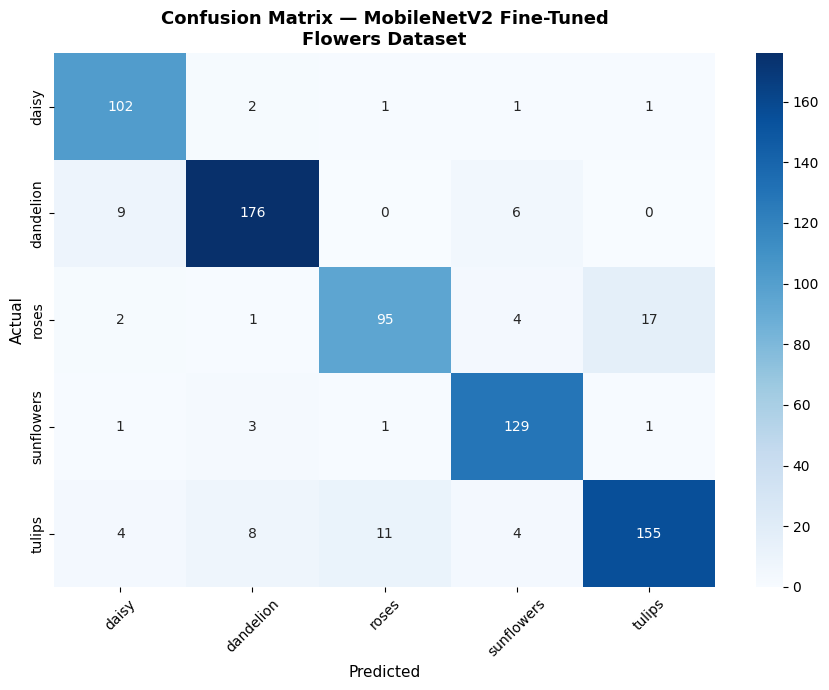

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — MobileNetV2 Fine-Tuned\nFlowers Dataset',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Training Curves

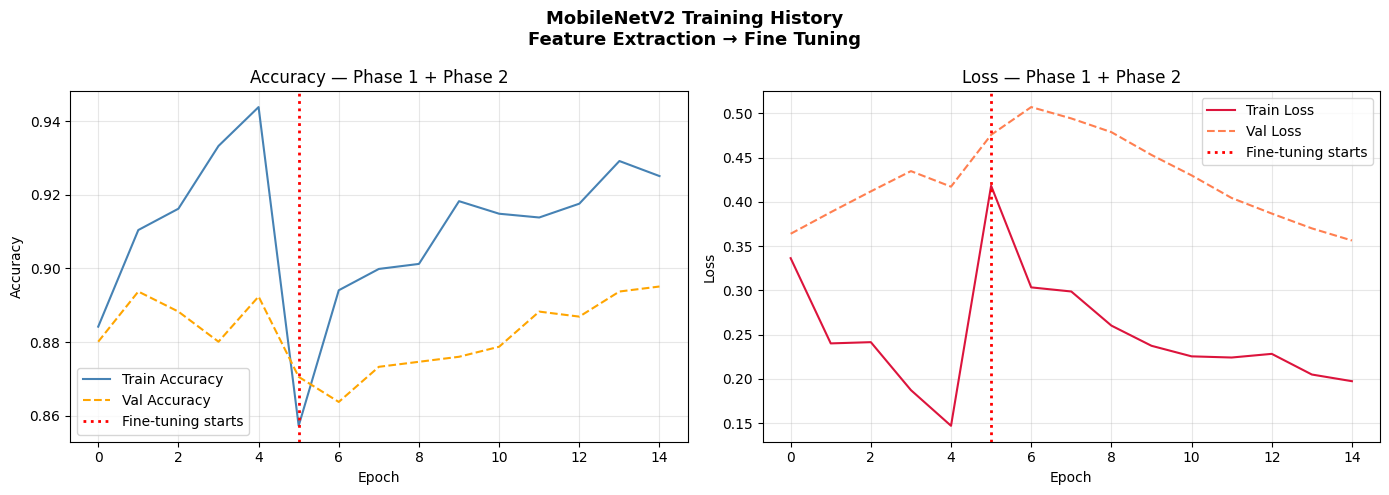

In [ ]:
# Combine Phase 1 and Phase 2 history
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']

# Where Phase 1 ends and Phase 2 begins
phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(acc,     label='Train Accuracy', color='steelblue')
axes[0].plot(val_acc, label='Val Accuracy',   color='orange',
             linestyle='--')
axes[0].axvline(x=phase1_end, color='red', linestyle=':',
                linewidth=2, label='Fine-tuning starts')
axes[0].set_title('Accuracy — Phase 1 + Phase 2')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(loss,     label='Train Loss', color='crimson')
axes[1].plot(val_loss, label='Val Loss',   color='coral',
             linestyle='--')
axes[1].axvline(x=phase1_end, color='red', linestyle=':',
                linewidth=2, label='Fine-tuning starts')
axes[1].set_title('Loss — Phase 1 + Phase 2')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 Training History\n'
             'Feature Extraction → Fine Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Sample Predictions

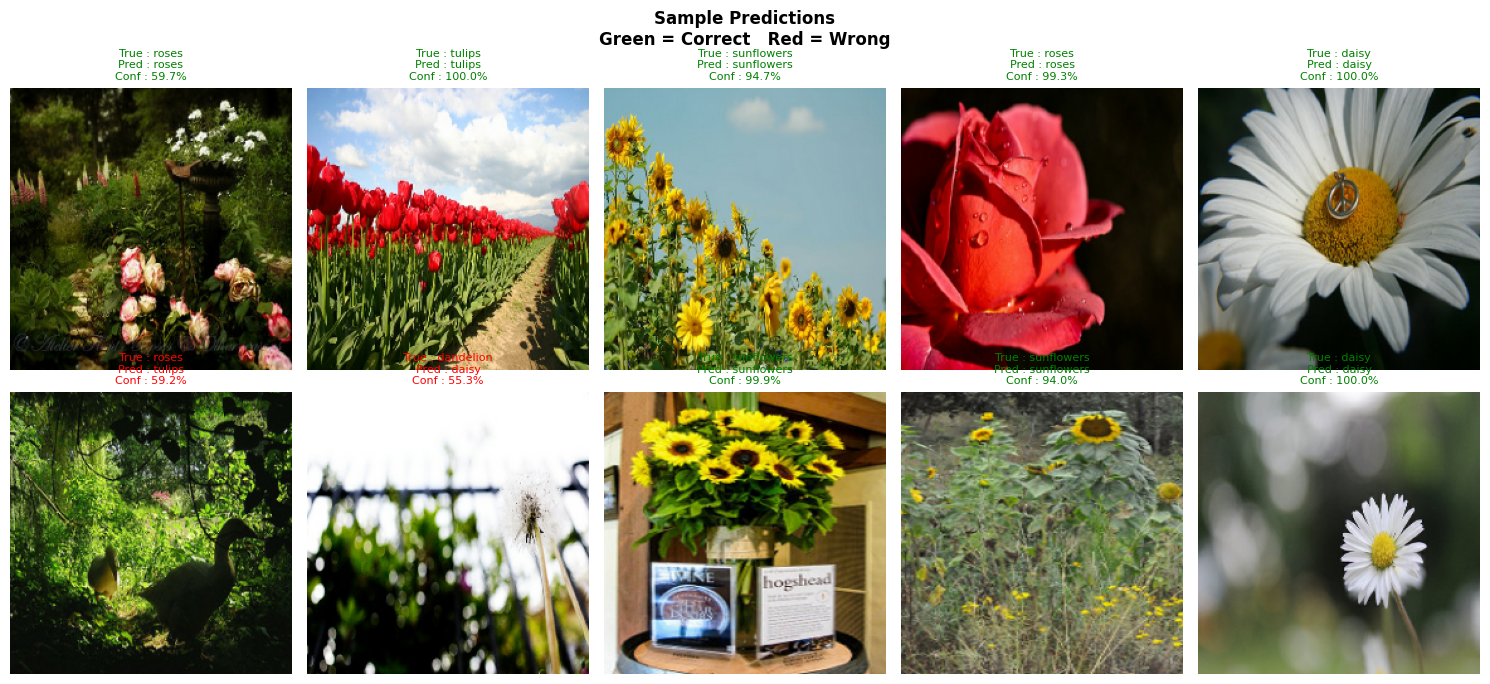

In [ ]:
# Show 10 sample predictions with confidence scores
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

# Get sample images from validation set
sample_images = []
sample_labels = []

for images, labels in val_ds.take(1):
    for i in range(10):
        sample_images.append(images[i].numpy())
        sample_labels.append(labels[i].numpy())

# Predict
sample_arr  = np.array(sample_images)
predictions = model.predict(sample_arr, verbose=0)

for i in range(10):
    pred_idx   = np.argmax(predictions[i])
    true_idx   = sample_labels[i]
    confidence = predictions[i][pred_idx] * 100

    axes[i].imshow(sample_images[i])
    color = 'green' if pred_idx == true_idx else 'red'
    axes[i].set_title(
        f"True : {class_names[true_idx]}\n"
        f"Pred : {class_names[pred_idx]}\n"
        f"Conf : {confidence:.1f}%",
        fontsize=8, color=color
    )
    axes[i].axis('off')

plt.suptitle(
    'Sample Predictions\nGreen = Correct   Red = Wrong',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Final performance summary
print("=" * 50)
print("      FINAL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"\n  Dataset       : Flowers (5 classes)")
print(f"  Model         : MobileNetV2 + Custom Head")
print(f"  Total epochs  : {len(acc)}")
print()
print(f"  Phase 1 (Frozen base)")
print(f"    Epochs      : {phase1_end}")
print(f"    Best val acc: {max(history1.history['val_accuracy']):.4f}")
print(f"    Time        : {time1/60:.1f} mins")
print()
print(f"  Phase 2 (Fine tuned)")
print(f"    Epochs      : {len(history2.history['accuracy'])}")
print(f"    Best val acc: {max(history2.history['val_accuracy']):.4f}")
print(f"    Time        : {time2/60:.1f} mins")
print()
print(f"  Final Test Accuracy : {test_acc:.4f}")
print(f"  Final Test Loss     : {test_loss:.4f}")
print(f"  Total Training Time : {(time1+time2)/60:.1f} mins")
print("=" * 50)

      FINAL PERFORMANCE SUMMARY

  Dataset       : Flowers (5 classes)
  Model         : MobileNetV2 + Custom Head
  Total epochs  : 15

  Phase 1 (Frozen base)
    Epochs      : 5
    Best val acc: 0.8937
    Time        : 1.4 mins

  Phase 2 (Fine tuned)
    Epochs      : 10
    Best val acc: 0.8951
    Time        : 2.4 mins

  Final Test Accuracy : 0.8951
  Final Test Loss     : 0.3564
  Total Training Time : 3.8 mins
